In [2]:
from time import time

import jax.numpy as jnp

from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import JPCConfig, QuantumParameters

On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = \sqrt{\kappa_a}  \left( \epsilon_a^* a + \epsilon_a a^\dagger \right) + \sqrt{\kappa_b}  \left( \epsilon_b^* b + \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \left[ \sqrt{\kappa_a}\; a \;, \;  \sqrt{\kappa_b}\; b \; , \; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) \right]$$


In [3]:
#X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1, -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1,
#              -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1, -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1 ])
#X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1,
#               -1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1])
X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7])


params_G = [QuantumParameters(
    g_conv=700,
    g_sq=20,
    epsilon_a=50,
    epsilon_b=50,
    delta_a=0,
    delta_b=0
)]

QP_Dudas = JPCConfig(
    DIM_A=12,
    DIM_B=12,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100
)

QP = QP_Dudas

chip = JpcChip(QP_Dudas)


In [4]:
t1 = time()
A_epsilon = chip.run_simulation(X, params_G, encoding_observable='epsilon')
#A_conv = chip.run_simulation(X, params_G, encoding_observable='g_conv')
#A_sq = chip.run_simulation(X, params_G, encoding_observable='g_sq')
print(time() - t1)

#c-profile

|██████████| 100.0% ◆ elapsed 12.40s ◆ remaining 0.00ms  


18.823829889297485


/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


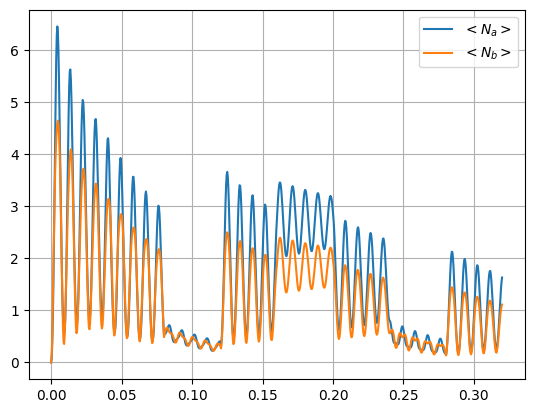

In [5]:
l = A_epsilon[0].photon_distribution.Plot_Mean_Photon_Number()
#l = A_conv[0].photon_distribution.Plot_Mean_Photon_Number()
#l = A_sq[0].photon_distribution.Plot_Mean_Photon_Number()

#l = A[0].photon_distribution.Plot_Sigma_Photon_Number()

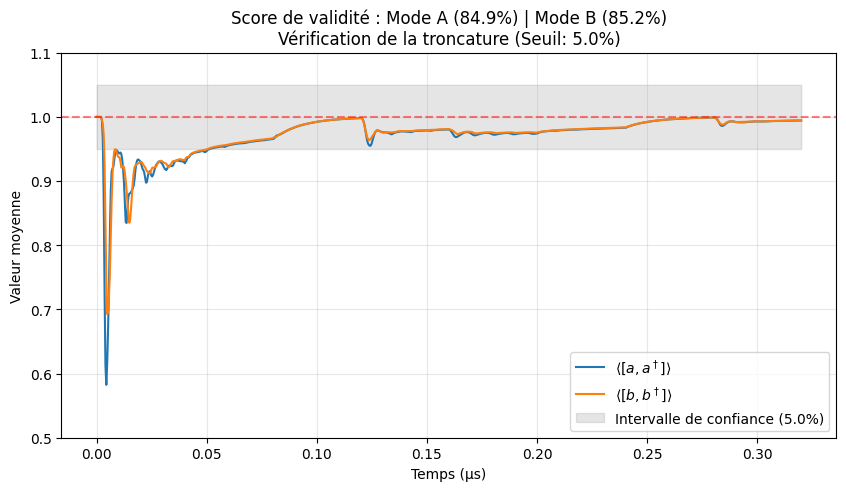

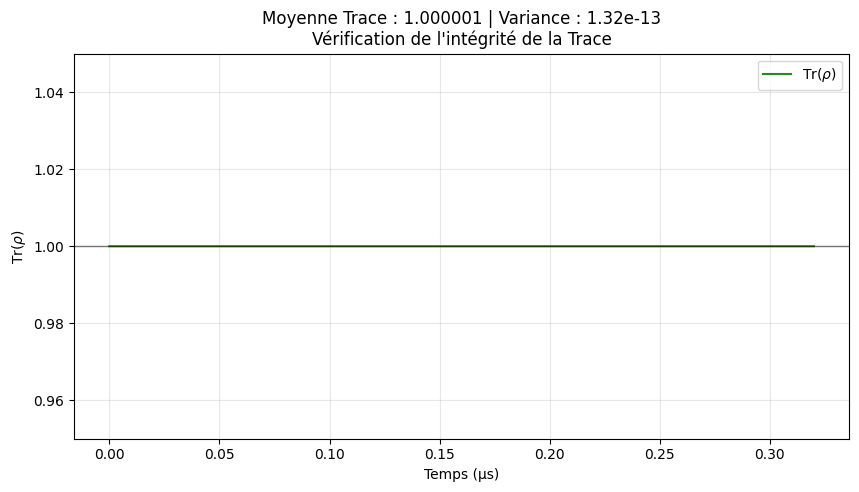

In [6]:
A_epsilon[0].plot_commutator_verification()
A_epsilon[0].plot_trace_integrity()

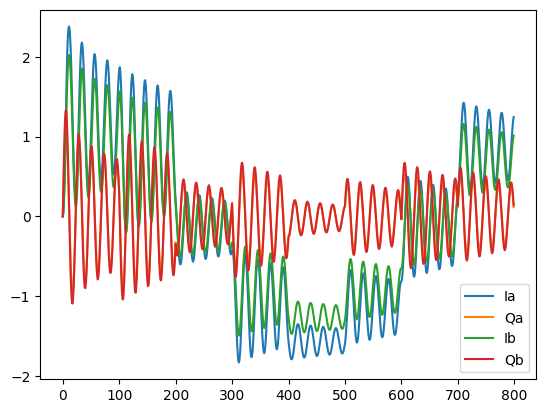

In [7]:
A_epsilon[0].quadratures.plot()

In [8]:
import numpy as np
import sys

# Pour afficher TOUT le tableau sans troncature
np.set_printoptions(threshold=sys.maxsize)

# Pour afficher un nombre précis de chiffres après la virgule (ex: 4)
np.set_printoptions(precision=4, suppress=True)

print(A_epsilon[0].quadratures.L_Ia.reshape(10, -1))

[[ 0.      0.0511  0.1998  0.4339  0.7345  1.0776  1.4358  1.7761  2.0581
   2.2486  2.3488  2.3795  2.3493  2.2565  2.1012  1.8871  1.6244  1.332
   1.0363  0.7642  0.5363  0.3673  0.2687  0.2474  0.3049  0.4364  0.6311
   0.8732  1.142   1.4158  1.6741  1.8952  2.0588  2.1538  2.1788  2.1371
   2.0327  1.8716  1.6649  1.427   1.1758  0.9325  0.7186  0.5501  0.4367
   0.3851  0.3998  0.4794  0.6166  0.8002  1.0162  1.2471  1.4742  1.6805
   1.851   1.9714  2.0319  2.0295  1.9669  1.8498  1.6858  1.4867  1.2686
   1.0493  0.8461  0.675   0.5489  0.4768  0.4633  0.5091  0.6107  0.7596
   0.9436  1.1479  1.3563  1.5528  1.7221  1.8514  1.931   1.955 ]
 [ 1.9219  1.8349  1.7017  1.5327  1.341   1.1415  0.9501  0.7817  0.6492
   0.5625  0.5279  0.5475  0.6193  0.7373  0.8921  1.0715  1.2613  1.4466
   1.613   1.7476  1.8402  1.8699  1.8174  1.6872  1.4904  1.2425  0.9644
   0.6765  0.4015  0.1615 -0.0255 -0.1455 -0.1899 -0.1558 -0.046   0.1302
   0.3586  0.6209  0.8965  1.164   1.4027  1.5

In [ ]:
%matplotlib widget

In [10]:
A_epsilon[0].photon_distribution.plot_joint_proba(use_log=True)

In [ ]:
A_epsilon[0].photon_distribution.plot_marginal_proba(mode='a')

In [14]:
A_epsilon[0].photon_distribution.plot_marginal_proba(mode='b', use_log=True)

In [22]:
A_epsilon[0].photon_distribution.P_b[-1]

Array([ 0.3378+0.j,  0.3652+0.j,  0.1969+0.j,  0.0708+0.j,  0.0197+0.j,
        0.0051+0.j,  0.0014+0.j,  0.0014+0.j, -0.0006+0.j,  0.0022+0.j,
       -0.0009+0.j,  0.0009+0.j], dtype=complex64)

In [51]:
import sympy as sp
from IPython.display import display, Math

# Variables
k1, k2 = sp.symbols('kappa1 kappa2', real=True)
g, gs = sp.symbols('g gs')

# Modules au carré
g2 = sp.Abs(g)**2
gs2 = sp.Abs(gs)**2

# Coefficients
p = g2 + gs2 + (k1**2 + k2**2)/4
q = (-g2 + gs2 - k1*k2/4)**2

# lambda^2
x_plus  = (-p + sp.sqrt(p**2 - 4*q)) / 2
x_minus = (-p - sp.sqrt(p**2 - 4*q)) / 2

# valeurs propres
lambdas = [
    sp.sqrt(x_plus), -sp.sqrt(x_plus),
    sp.sqrt(x_minus), -sp.sqrt(x_minus)
]

# Affichage LaTeX
for lam in lambdas:
    display(Math(sp.latex(sp.simplify(lam))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [49]:
eigs

{Piecewise((-kappa1/4 - kappa2/4 - sqrt(-2*delta1**2/3 - 2*delta2**2/3 - 4*g*conjugate(g)/3 + 4*gs*conjugate(gs)/3 - kappa1**2/6 - 2*kappa1*kappa2/3 - kappa2**2/6 + (kappa1 + kappa2)**2/4 - 2*(-(-delta1**2*kappa1/2 + delta1**2*kappa2/2 + delta2**2*kappa1/2 - delta2**2*kappa2/2)**2/8 - (delta1**2 + delta2**2 + 2*g*conjugate(g) - 2*gs*conjugate(gs) + kappa1**2/4 + kappa1*kappa2 + kappa2**2/4 - 3*(kappa1 + kappa2)**2/8)**3/108 + (delta1**2 + delta2**2 + 2*g*conjugate(g) - 2*gs*conjugate(gs) + kappa1**2/4 + kappa1*kappa2 + kappa2**2/4 - 3*(kappa1 + kappa2)**2/8)*(delta1**2*delta2**2 + delta1**2*kappa1**2/16 - delta1**2*kappa1*kappa2/8 + delta1**2*kappa2**2/16 - 2*delta1*delta2*g*conjugate(g) - 2*delta1*delta2*gs*conjugate(gs) + delta2**2*kappa1**2/16 - delta2**2*kappa1*kappa2/8 + delta2**2*kappa2**2/16 - g**2*gs*conjugate(gs) + g**2*conjugate(g)**2 - g*kappa1**2*conjugate(g)/8 + g*kappa1*kappa2*conjugate(g)/4 - g*kappa2**2*conjugate(g)/8 + gs**2*conjugate(gs)**2 + gs*kappa1**2*conjugate(gs

In [50]:
sp.latex(eigs)

'\\left\\{ \\begin{cases} - \\frac{\\kappa_{1}}{4} - \\frac{\\kappa_{2}}{4} - \\frac{\\sqrt{- \\frac{2 \\delta_{1}^{2}}{3} - \\frac{2 \\delta_{2}^{2}}{3} - \\frac{4 g \\overline{g}}{3} + \\frac{4 gs \\overline{gs}}{3} - \\frac{\\kappa_{1}^{2}}{6} - \\frac{2 \\kappa_{1} \\kappa_{2}}{3} - \\frac{\\kappa_{2}^{2}}{6} + \\frac{\\left(\\kappa_{1} + \\kappa_{2}\\right)^{2}}{4} - 2 \\sqrt[3]{- \\frac{\\left(- \\frac{\\delta_{1}^{2} \\kappa_{1}}{2} + \\frac{\\delta_{1}^{2} \\kappa_{2}}{2} + \\frac{\\delta_{2}^{2} \\kappa_{1}}{2} - \\frac{\\delta_{2}^{2} \\kappa_{2}}{2}\\right)^{2}}{8} - \\frac{\\left(\\delta_{1}^{2} + \\delta_{2}^{2} + 2 g \\overline{g} - 2 gs \\overline{gs} + \\frac{\\kappa_{1}^{2}}{4} + \\kappa_{1} \\kappa_{2} + \\frac{\\kappa_{2}^{2}}{4} - \\frac{3 \\left(\\kappa_{1} + \\kappa_{2}\\right)^{2}}{8}\\right)^{3}}{108} + \\frac{\\left(\\delta_{1}^{2} + \\delta_{2}^{2} + 2 g \\overline{g} - 2 gs \\overline{gs} + \\frac{\\kappa_{1}^{2}}{4} + \\kappa_{1} \\kappa_{2} + \\frac{\\kappa